### Ładowanie danych

In [30]:
import sys, json, subprocess
from pathlib import Path

import json
import re

import seaborn as sns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = PROJECT_ROOT / 'data' / 'single-cell-tracks_exp1-6_noErbB2.csv'
META_PATH    = PROJECT_ROOT / 'data' / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'analysis_outputs'

EXP_ID     = 1
SITE_ID    = 1
SIGNAL_COL = 'ERKKTR_ratio'

def run_block(exp, site, signal, radius, window, quantile, threshold=None):
    """Run the single-block script and return the parsed summary dict."""
    tag   = f'exp_{exp}_site_{site}_{signal}_r{radius}_w{window}_q{int(quantile*100)}'
    outdir = OUTPUT_ROOT / tag
    cmd = [
        sys.executable,
        str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
        '--data-path',            str(DATA_PATH),
        '--meta-path',            str(META_PATH),
        '--exp-id',               str(exp),
        '--site-id',              str(site),
        '--signal-col',           signal,
        '--spatial-radius',       str(radius),
        '--future-window-frames', str(window),
        '--jump-quantile',        str(quantile),
        '--output-dir',           str(outdir.parent),
    ]
    if threshold is not None:
        cmd += ['--jump-threshold', str(threshold)]
    subprocess.run(cmd, capture_output=True)
    summary_path = outdir / 'summary.json'
    if not summary_path.exists():
        # fallback: script may have used default output naming
        summary_path = OUTPUT_ROOT / f'exp_{exp}_site_{site}_{signal}' / 'summary.json'
    with open(summary_path) as f:
        return json.load(f)

print('Setup complete.')

Setup complete.


In [31]:
radii = range(15, 200, 15) # for a more informative plot
rows_r = []
for r in radii:
    print(f'  running r={r} …', end=' ', flush=True)
    # Re-use standard output dir for r=60 (already computed in Block 1)
    if r == 60:
        outpath = OUTPUT_ROOT / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
        with open(outpath) as f:
            s = json.load(f)
    else:
        outdir = OUTPUT_ROOT / f'sweep_r{r}'
        cmd = [
            sys.executable, str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),
            '--data-path', str(DATA_PATH), '--meta-path', str(META_PATH),
            '--exp-id', str(EXP_ID), '--site-id', str(SITE_ID),
            '--signal-col', SIGNAL_COL,
            '--spatial-radius', str(r),
            '--future-window-frames', '3',
            '--jump-quantile', '0.9',
            '--output-dir', str(outdir),
        ]
        subprocess.run(cmd, capture_output=True)
        sp = next((outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}').glob('summary.json'), None)
        if sp is None:
            sp = outdir / f'exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}' / 'summary.json'
        with open(sp) as f:
            s = json.load(f)
    rows_r.append({
        'r': r,
        '|E_sp|': s['n_spatial_edges'],
        'θ': round(s['jump_threshold'], 4),
        'p_exp': round(s['future_jump_rate_if_neighbor_jumps_now'], 4),
        'p_unexp': round(s['future_jump_rate_if_no_neighbor_jumps_now'], 4),
        'RR': round(s['relative_risk'], 4),
        'RD': round(s['risk_difference'], 4),
    })
    print('done')

df_r = pd.DataFrame(rows_r).set_index('r')

  running r=15 … done
  running r=30 … done
  running r=45 … done
  running r=60 … done
  running r=75 … done
  running r=90 … done
  running r=105 … done
  running r=120 … done
  running r=135 … done
  running r=150 … done
  running r=165 … done
  running r=180 … done
  running r=195 … done


In [ ]:
summary_files = sorted(OUTPUT_ROOT.glob('sweep_r*/exp_1_site_1_ERKKTR_ratio/summary.json'))

rows=[]
for file in summary_files:
    with open(file) as f:
        data = json.load(f)

    m = re.search(r"sweep_r(\d+)", str(file))
    data["spatial_radius"] = int(m.group(1)) if m else None

    rows.append(data)


,exp_id,site_id,mutation,signal_col,spatial_radius,future_window_frames,jump_threshold,n_nodes,n_spatial_edges,n_temporal_edges,n_tracks,n_frames,n_exposed_nodes,n_unexposed_nodes,future_jump_rate_if_neighbor_jumps_now,future_jump_rate_if_no_neighbor_jumps_now,risk_difference,relative_risk
3,1,1,WT,ERKKTR_ratio,15,3,0.036543,356632,8168,354834,1798,258,1086,355546,0.327808,0.097430,0.230378,3.364539
8,1,1,WT,ERKKTR_ratio,30,3,0.036543,356632,508839,354834,1798,258,43171,313461,0.179704,0.086898,0.092806,2.067998
9,1,1,WT,ERKKTR_ratio,45,3,0.036543,356632,1304572,354834,1798,258,94198,262434,0.149653,0.079639,0.070014,1.879139
10,1,1,WT,ERKKTR_ratio,75,3,0.036543,356632,3761864,354834,1798,258,196896,159736,0.119352,0.071975,0.047377,1.658247
11,1,1,WT,ERKKTR_ratio,90,3,0.036543,356632,5401402,354834,1798,258,239638,116994,0.111981,0.069764,0.042217,1.605140
0,1,1,WT,ERKKTR_ratio,105,3,0.036543,356632,7283073,354834,1798,258,274148,82484,0.106851,0.069153,0.037698,1.545144
1,1,1,WT,ERKKTR_ratio,120,3,0.036543,356632,9409711,354834,1798,258,300523,56109,0.103323,0.070327,0.032996,1.469174
2,1,1,WT,ERKKTR_ratio,135,3,0.036543,356632,11760201,354834,1798,258,319585,37047,0.101194,0.071720,0.029474,1.410961
4,1,1,WT,ERKKTR_ratio,150,3,0.036543,356632,14339412,354834,1798,258,332701,23931,0.099786,0.075133,0.024654,1.328134
5,1,1,WT,ERKKTR_ratio,165,3,0.036543,356632,17101032,354834,1798,258,341182,15450,0.099006,0.078835,0.020171,1.255862


### wizualizacja

<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_18790/4062345470.py:23: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel("Spatial Radius $r$ ($\mu m$ or pixels)", fontsize=11)


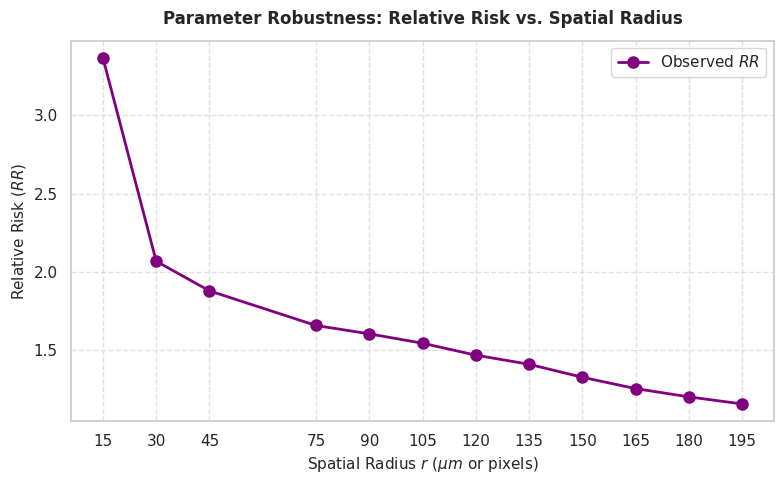

In [ ]:
# 3. Generowanie wykresu Robustness Assessment
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Rysujemy linię z punktami (line + scatter)
plt.plot(
    df["spatial_radius"],
    df["relative_risk"],
    marker="o",
    linewidth=2,
    color="purple",
    markersize=8,
    label="Observed $RR$",
)

# Stylizacja wykresu
plt.title(
    "Parameter Robustness: Relative Risk vs. Spatial Radius",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.xlabel("Spatial Radius $r$ ($\mu m$ or pixels)", fontsize=11)
plt.ylabel("Relative Risk ($RR$)", fontsize=11)
plt.xticks(df["spatial_radius"].unique())
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

import os
os.makedirs(PROJECT_ROOT / 'A_3' / 'task_outputs', exist_ok=True)
plt.savefig(PROJECT_ROOT / 'A_3' / 'task_outputs' / 'parameter_robustness.png', dpi=300, bbox_inches='tight')

plt.tight_layout()
plt.show()

### Interpretacja

Relatywne ryzyko jest odwrotnie proporcjonalne do "Spatial Radius", im bliżej komórka jest drugiej komórki - tym bardziej ryzyko rośnie. 

RR gwałtownie spada między 15 a 30, po czym zaczyna łagodnie opadać, co wskazuje na istotność tego parametru.
Dla wartości niskich (15-30) zbyt bardzo zawężamy ilość sąsiadujących komórek co może wprowadzić szum stochastyczny. Natomiast dla wartości wysokich (od 75) wprowadzamy dużo komórek znacznie oddalonych, co powoduje efekt rozcieńczenia - nieisitone komórki zaczynają dominować dane. Należy odnaleźć "złoty środek" - wartości 45-60.
